In [ ]:
import polars as pl
import utils
from run_capsule import sessions_with_good_fold_coverage

In [2]:
DATACUBE_VERSION = 'v0.0.289'

In [10]:
class Params:
    good_block_dprime_threshold = 1.0
    good_block_min_contingent_rewards = 10

params = Params()

In [26]:
trials = pl.read_parquet(f'/root/capsule/data/dynamicrouting_datacube_{DATACUBE_VERSION}/consolidated/trials.parquet')
    
session_table = pl.read_parquet(f'/root/capsule/data/dynamicrouting_datacube_{DATACUBE_VERSION}/session_table.parquet')
good_behavior_sessions = session_table.filter(pl.col('is_good_behavior'))['session_id'].to_list()
sessions_to_analyze = (
    utils.get_df('session')
    .filter(
        #pl.col('keywords').list.contains('production'),
        ~pl.col('keywords').list.contains('templeton'),
        ~pl.col('keywords').list.contains('injection_perturbation'),
        ~pl.col('keywords').list.contains('injection_control'),
        ~pl.col('keywords').list.contains('opto_perturbation'),
        ~pl.col('keywords').list.contains('opto_control'),
        ~pl.col('keywords').list.contains('issues'),
        ~pl.col('keywords').list.contains('naive'),
        ~pl.col('keywords').list.contains('context_naive'),
        pl.col('session_id').is_in(good_behavior_sessions),
    )
)
trials = trials.filter(pl.col('session_id').is_in(sessions_to_analyze['session_id'].implode()))

n_sessions_before_block_filter = trials['session_id'].n_unique()
eligible_sessions = sessions_with_good_fold_coverage(
    trials, utils.get_df('performance'), params
)
trials = trials.filter(pl.col('session_id').is_in(eligible_sessions))

In [27]:
trials

start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct,session_idx,date,subject_id,session_id,id,opto_start_time,opto_stop_time,opto_wavelength,opto_location_bregma_x,opto_location_bregma_y,opto_duration,opto_label,opto_power,opto_stim_name,is_single_opto_location
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,i64,str,i64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,i64,date,i64,str,i64,f64,f64,f64,f64,f64,f64,str,f64,str,bool
85.7625,91.26691,85.7625,87.2302,87.29094,87.79137,87.34692,88.26434,87.98116,87.97838,87.3636,88.29178,91.29429,"""vis1""",0.0,0,"""vis""",0,0.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",0,null,null,null,null,null,null,null,null,null,null
91.93403,97.43867,91.93403,93.40193,93.46277,93.96319,93.51867,94.43624,94.10252,94.09598,93.53536,94.4636,97.4661,"""vis1""",0.0,0,"""vis""",1,1.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",1,null,null,null,null,null,null,null,null,null,null
98.5062,104.01127,98.5062,99.9741,100.03491,100.53533,100.09095,101.00829,100.34111,100.34042,100.10758,101.03576,104.03827,"""vis1""",0.0,0,"""vis""",2,2.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",2,null,null,null,null,null,null,null,null,null,null
105.22842,110.73305,105.22842,106.69634,106.7572,107.25762,106.81309,107.73057,107.03017,107.02306,106.82981,107.75805,110.760545,"""vis1""",0.5,0,"""vis""",3,3.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",3,null,null,null,null,null,null,null,null,null,null
111.78396,117.28853,111.78396,113.25187,113.31269,113.8131,113.36861,114.28608,113.56879,113.56762,113.38531,114.31351,117.31604,"""vis1""",0.5,0,"""vis""",4,4.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",4,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5747.15466,5752.69262,5747.15466,5748.6393,5748.700211,5749.200621,5748.75603,5749.67346,null,null,null,5749.701041,5752.720241,"""vis2""",0.5,5,"""aud""",537,83.0,0.0,false,true,false,false,false,true,false,false,true,false,false,false,false,false,false,true,false,false,false,false,true,false,true,false,true,false,false,false,false,0,2025-10-22,805752,"""805752_2025-10-22""",537,null,null,null,null,null,null,null,null,null,null
5753.96037,5759.48173,5753.96037,5755.42823,5755.4694,5755.9694,5755.54503,5756.46248,5755.89533

In [25]:
s = utils.get_df('session')

'production' in s.select('keywords').explode('keywords')

/tmp/ipykernel_961/2443068718.py:3: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  'production' in s.select('keywords').explode('keywords')


False

## ANALYSIS

In [1]:
import json
import polars as pl
from upath import UPath
import numpy as np
from matplotlib import pyplot as plt

In [2]:
s3_uri = "s3://aind-scratch-data/dynamic-routing/neural_trajectory_separation_all_conditions"

In [3]:

run_name = "crossval_082626"
# This bucket is public, so explicitly use unsigned (anonymous) S3 requests.
s3_root = UPath(s3_uri, anon=True)

# Parameters are stored beside (rather than inside) the run directory.
trajectory_params = json.loads((s3_root / f"{run_name}.json").read_text())

# Results are one parquet per area/condition-pair in the run subdirectory.
run_dir = s3_root / run_name
available_parquet_paths = sorted(run_dir.glob("*.parquet"))

# Set this to a list of filenames (e.g. ["MOs_0.parquet", "MOs_1.parquet"])
# to load only selected results. Leave as None to load every parquet in the run.
parquet_filenames = None
parquet_paths = (
    available_parquet_paths
    if parquet_filenames is None
    else [run_dir / filename for filename in parquet_filenames]
)

# Give Polars S3FS file handles so it uses the same anonymous connection.
trajectory_results = {}
for path in parquet_paths:
    with path.open("rb") as parquet_file:
        trajectory_results[path.stem] = pl.read_parquet(parquet_file)

print(f"Loaded parameters and {len(trajectory_results)} parquet file(s).")
print("Available parquet files:", [path.name for path in available_parquet_paths])
trajectory_params


Loaded parameters and 1875 parquet file(s).
Available parquet files: ['ACAd_0.parquet', 'ACAd_1.parquet', 'ACAd_10.parquet', 'ACAd_11.parquet', 'ACAd_12.parquet', 'ACAd_13.parquet', 'ACAd_14.parquet', 'ACAd_2.parquet', 'ACAd_3.parquet', 'ACAd_4.parquet', 'ACAd_5.parquet', 'ACAd_6.parquet', 'ACAd_7.parquet', 'ACAd_8.parquet', 'ACAd_9.parquet', 'ACAv_0.parquet', 'ACAv_1.parquet', 'ACAv_10.parquet', 'ACAv_11.parquet', 'ACAv_12.parquet', 'ACAv_13.parquet', 'ACAv_14.parquet', 'ACAv_2.parquet', 'ACAv_3.parquet', 'ACAv_4.parquet', 'ACAv_5.parquet', 'ACAv_6.parquet', 'ACAv_7.parquet', 'ACAv_8.parquet', 'ACAv_9.parquet', 'ACB_0.parquet', 'ACB_1.parquet', 'ACB_10.parquet', 'ACB_11.parquet', 'ACB_12.parquet', 'ACB_13.parquet', 'ACB_14.parquet', 'ACB_2.parquet', 'ACB_3.parquet', 'ACB_4.parquet', 'ACB_5.parquet', 'ACB_6.parquet', 'ACB_7.parquet', 'ACB_8.parquet', 'ACB_9.parquet', 'AD_0.parquet', 'AD_1.parquet', 'AD_10.parquet', 'AD_11.parquet', 'AD_12.parquet', 'AD_13.parquet', 'AD_14.parquet', 'AD

{'intervals_table': 'trials',
 'align_to_col': 'stim_start_time',
 'pre': 0.5,
 'post': 0.5,
 'default_qc_only': True,
 'as_spike_count': False,
 'as_binarized_array': True,
 'bin_size_s': 0.001,
 'datacube_version': 'v0.0.289',
 'spike_col': 'binarized_spike_times',
 'input_dir_name': '2026-08-20',
 'conv_kernel_s': 0.025,
 'decoder_areas_to_average': ['ACAd',
  'AId',
  'AIp',
  'CP',
  'FRP',
  'ILA',
  'MOp',
  'MOs',
  'MRN',
  'ORBl',
  'ORBvl',
  'PL',
  'SCm',
  'SSp',
  'SSs'],
 'baseline_start_s': -0.5,
 'baseline_end_s': -0.025,
 'baseline_rate_floor_hz': 1.0,
 'projection_stimulus_start_s': 0.0,
 'projection_stimulus_end_s': 0.1,
 'good_block_dprime_threshold': 1.0,
 'good_block_min_contingent_rewards': 10,
 'integer_id_to_condition_mapping': {'0': [['is_aud_target',
    'is_aud_rewarded',
    'is_hit'],
   ['is_aud_target', 'is_vis_rewarded', 'is_correct_reject']],
  '1': [['is_aud_target', 'is_aud_rewarded', 'is_hit'],
   ['is_aud_target', 'is_vis_rewarded', 'is_false_ala

In [4]:
mapping = trajectory_params['integer_id_to_condition_mapping']

In [5]:
trajectory_results['ORBm_0']['baseline_separation'].hist()

breakpoint,category,count
f64,cat,u32
-1.14873,"""[-1.40827, -1.14873]""",1
-0.88919,"""(-1.14873, -0.88919]""",0
-0.62965,"""(-0.88919, -0.62965]""",0
-0.37011,"""(-0.62965, -0.37011]""",1
-0.11057,"""(-0.37011, -0.11057]""",2
0.14897,"""(-0.11057, 0.14897]""",0
0.40851,"""(0.14897, 0.40851]""",0
0.66805,"""(0.40851, 0.66805]""",0
0.92759,"""(0.66805, 0.92759]""",0


In [6]:
trajectory_results['ORBm_0']

session_id,traj_separation,traj_separation_rate_normalized,traj_separation_raw,baseline_separation,median_baseline_rate_hz,n_units_below_rate_floor,baseline_axis_projection,baseline_axis_projection_condition_1,baseline_axis_projection_condition_2,orthogonal_stimulus_projection,baseline_axis_alignment,orthogonal_axis_alignment,n_units,fold_1_blocks,fold_2_blocks,condition_pair_id
str,list[f64],list[f64],list[f64],f64,f64,i64,list[f64],list[f64],list[f64],list[f64],f64,f64,i64,list[i64],list[i64],i32
"""664851_2023-11-16""","[-0.295674, -0.48735, … 1.298082]","[0.283751, 0.224626, … 0.482253]","[-0.820128, -0.736463, … 0.661218]",0.941485,1.868795,12,"[-0.462048, -0.386415, … -0.726072]","[-0.047053, -0.073197, … -0.133982]","[0.414995, 0.313218, … 0.59209]","[0.576869, 0.463634, … 0.593591]",0.385013,0.038789,43,"[0, 1, 2]","[3, 4, 5]",0
"""690706_2023-11-28""","[1.307126, 2.389354, … 1.956395]","[0.215421, 0.083328, … -0.481043]","[1.709085, 2.267009, … -1.770118]",-1.40827,0.780997,8,"[0.939824, 0.521875, … -1.4901]","[1.099042, 1.099042, … -0.681186]","[0.159218, 0.577166, … 0.808914]","[0.321036, 0.271244, … 0.544204]",-0.532678,-0.540436,15,"[0, 1, 2]","[3, 4, 5]",0
"""714748_2024-06-24""","[0.345673, 0.307312, … 1.091863]","[0.230599, 0.251575, … 0.482233]","[0.318103, 0.463938, … 1.177616]",-0.323745,0.46687,23,"[-0.00543, 0.050303, … 0.034823]","[0.398063, 0.308748, … 0.655535]","[0.403493, 0.258445, … 0.620712]","[0.440536, 0.439526, … -0.008734]",-0.174132,-0.149782,31,"[0, 1, 2]","[3, 4, 5]",0
"""737403_2024-09-24""","[-0.409599, -0.467348, … 0.529339]","[-0.253382, -0.314962, … 0.181172]","[-0.342301, -0.483716, … 0.784585]",-0.346836,0.47242,41,"[0.175212, 0.119353, … 0.418337]","[-0.008331, -0.027425, … 0.078273]","[-0.183542, -0.146778, … -0.340063]","[0.039717, 0.090956, … 0.348588]",-0.383943,-0.059855,65,"[0, 1, 2]","[3, 4, 5]",0
"""742903_2024-10-21""","[1.143842, 1.557054, … 1.533552]","[-0.323707, -0.232265, … -0.156195]","[0.867576, 1.287898, … 1.165719]",-0.613533,0.976877,24,"[-0.077856, -0.170069, … -0.277284]","[-0.030548, -0.172931, … 0.008604]","[0.047308, -0.002862, … 0.285888]","[1.004756, 1.12922, … -1.006012]",-0.293765,0.11109,47,"[0, 1, 2]","[3, 4, 5]",0
"""742903_2024-10-22""","[0.599974, 0.694294, … 0.504947]","[-0.359173, -0.337903, … 0.168462]","[1.045843, 1.103836, … -0.682339]",1.18713,0.967825,22,"[-0.194377, -0.192902, … -0.634952]","[-0.040299, -0.071351, … 0.314351]","[0.154078, 0.121551, … 0.949303]","[0.248169, 0.163512, … 0.125646]",0.490659,0.423487,44,"[0, 1, 2]","[3, 4, 5]",0


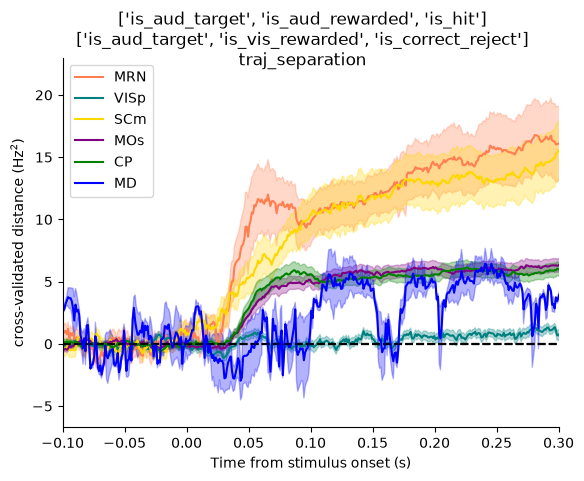

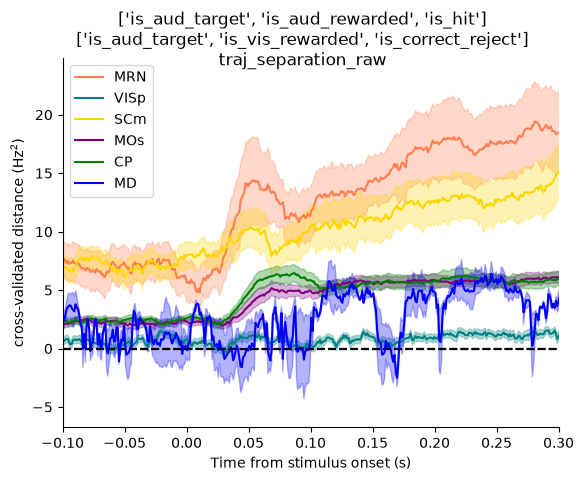

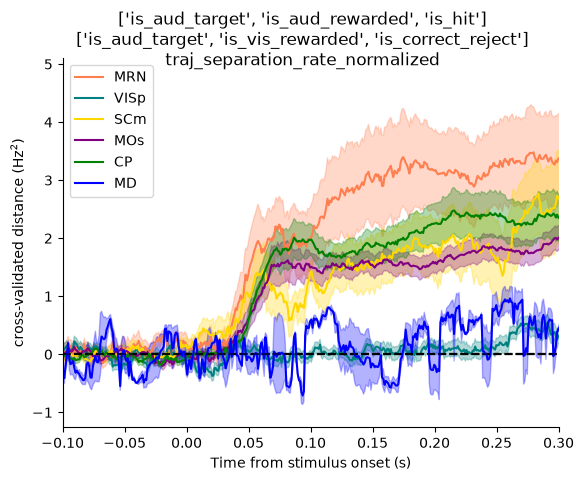

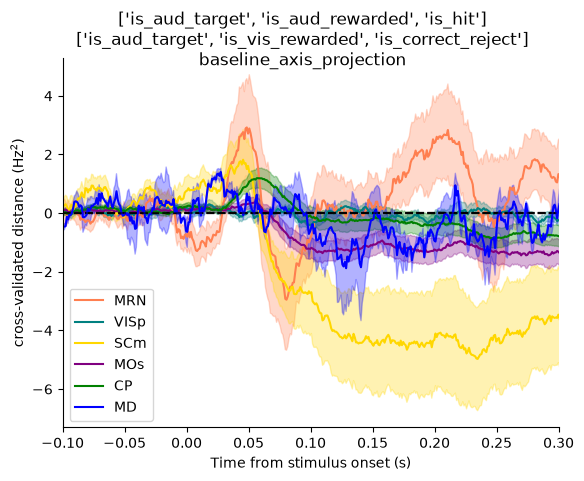

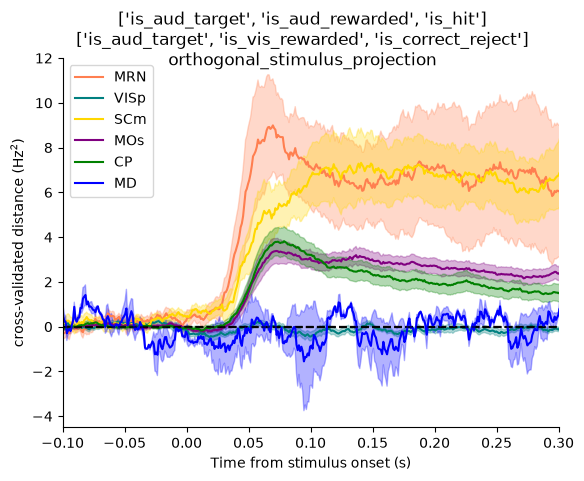

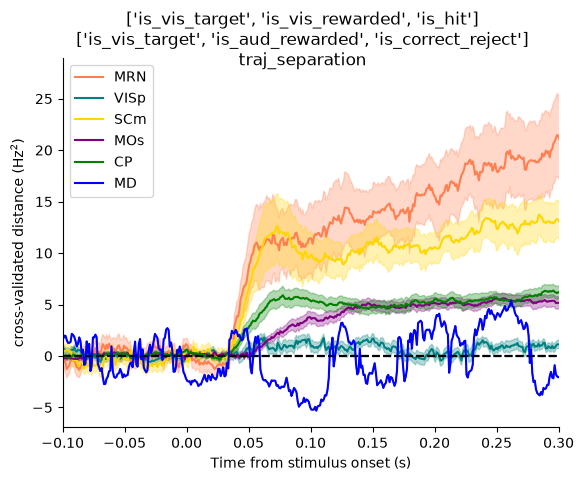

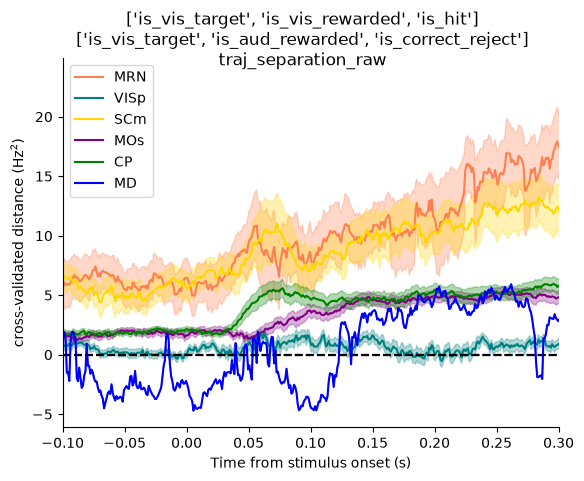

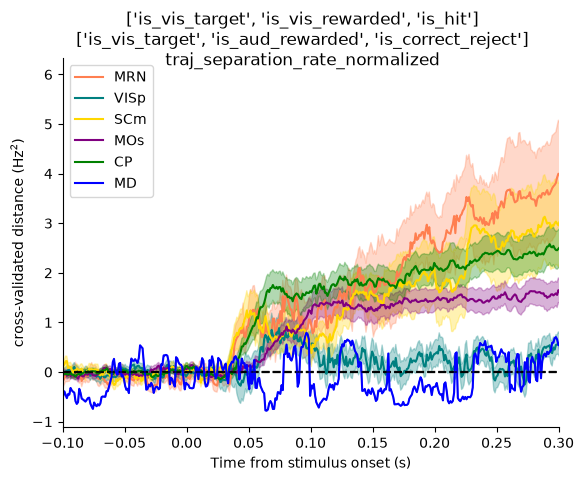

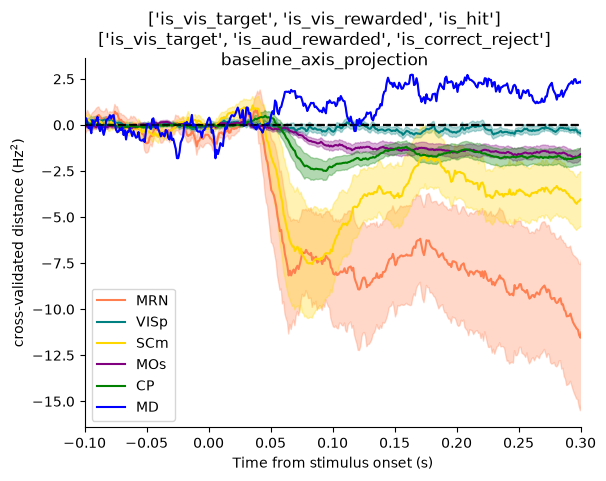

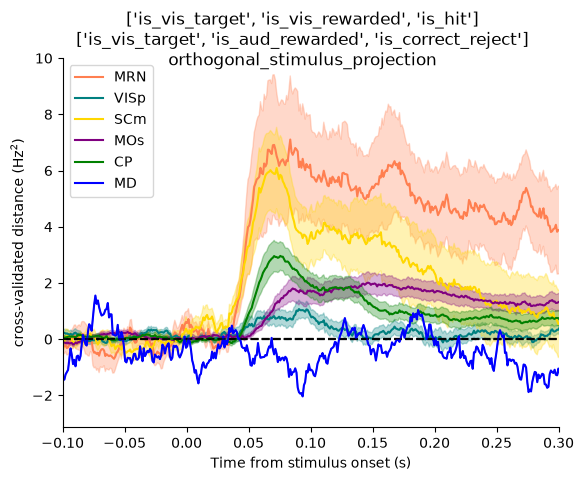

In [14]:
conditions_to_plot = [0,3]
show_sessions = False
regions = ['MRN', 'VISp', 'SCm', 'MOs', 'CP', 'MD']# 'MOs', 'CP', 'PL']
colors = {'MRN': 'coral',
          'VISp': 'teal',
          'SCm': 'gold',
          'MOs': 'purple',
          'CP': 'green',
          'MD': 'blue',
          #'PL': 'brown'
          }
time = np.linspace(-0.5, 0.5, 1000)
for condition in conditions_to_plot:

    for col in ['traj_separation', 'traj_separation_raw', 'traj_separation_rate_normalized', 'baseline_axis_projection', 'orthogonal_stimulus_projection']:
        fig, ax = plt.subplots()
        fig.suptitle(f"{mapping[str(condition)][0]}\n{mapping[str(condition)][1]}\n{col}")
        for region in regions:
            results = np.stack(trajectory_results[f'{region}_{condition}'][col].to_numpy())
            if results.shape[0] > 0:
                mean_results = np.nanmean(results, axis=0)
                sem_results = np.nanstd(results, axis=0) / np.sqrt(results.shape[0])
                ax.plot(time, mean_results, label=region, color=colors[region])
                ax.fill_between(time, mean_results - sem_results, mean_results + sem_results, color=colors[region], alpha=0.3)
                ax.set_xlim([-0.1,0.3])
                #also plot individual sessions in low alpha
                if show_sessions:
                    for session_result in results:
                        ax.plot(time, session_result, color=colors[region], alpha=0.1)
                ax.legend()
                #remove top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.set_xlabel('Time from stimulus onset (s)')
                ax.set_ylabel('cross-validated distance (Hz$^2$)')
                ax.axhline(0, color='k', linestyle='--', alpha=0.5)

In [9]:
BASELINE_SLICE = slice(400, 500)
STIMULUS_SLICE = slice(500, 600)
RESPONSE_SLICE = slice(900, 1000)

In [25]:
regions

structure
str
"""ACAd"""
"""ACAv"""
"""ACB"""
"""AD"""
"""AId"""
…
"""ZI"""
"""lot"""
"""out of brain"""


In [11]:
from importlib import reload
from dynamic_routing_analysis import ccf_utils
reload(ccf_utils)

<module 'dynamic_routing_analysis.ccf_utils' from '/Users/corbettb/Documents/GitHub/dynamic_routing_analysis/src/dynamic_routing_analysis/ccf_utils.py'>

In [51]:
trajectory_results['MD_0']['session_id']#.cast(pl.Utf8).str.split('_').list.get(0)#.n_unique()

session_id
str
"""712815_2024-05-21"""
"""737403_2024-09-24"""


In [40]:
def _nanmean(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)) if not np.all(np.isnan(values)) else np.nan


def _session_window_mean(results, column, window):
    if results.height == 0:
        return np.nan

    vectors = np.stack(results[column].to_list())
    return _nanmean(vectors[:, window])

#Select only those regions for which there is data from at least 3 different mice
def _region_session_filter(trajectory_results, region_condition_key, min_mice_with_data=3):
    traj_data = trajectory_results[region_condition_key]
    num_mice = traj_data['session_id'].cast(pl.Utf8).str.split('_').list.get(0).n_unique()
    return num_mice >= min_mice_with_data

# Use only regions for which both requested condition files are available.
region_condition_keys = {
    condition: {
        key.rsplit('_', 1)[0]: key
        for key in trajectory_results
        if key.endswith(f'_{condition}')
    }
    for condition in (0, 3)
}
regions = sorted(set(region_condition_keys[0]) & set(region_condition_keys[3]))

window_specs = {
    'baseline': ('traj_separation_raw', BASELINE_SLICE),
    'stimulus': ('traj_separation', STIMULUS_SLICE),
    'response': ('traj_separation', RESPONSE_SLICE),
    'normed_stimulus': ('traj_separation_rate_normalized', STIMULUS_SLICE),
}

results = []
for region in regions:
    if region=='out of brain' or 'ventricle' in ccf_utils.get_ccf_structure_info(region)['name']:
        continue
    row = {'structure': region}
    for window_name, (column, window) in window_specs.items():
        for condition in (0, 3):
            key = region_condition_keys[condition][region]
            if _region_session_filter(trajectory_results, key):
                row[f'{window_name}_{condition}'] = _session_window_mean(
                    trajectory_results[key], column, window
                )
            else:
                row[f'{window_name}_{condition}'] = np.nan

        row[f'{window_name}_mean'] = _nanmean(
            [row[f'{window_name}_0'], row[f'{window_name}_3']]
        )
    results.append(row)

results_pd = pl.DataFrame(results)
results_pd

structure,baseline_0,baseline_3,baseline_mean,stimulus_0,stimulus_3,stimulus_mean,response_0,response_3,response_mean,normed_stimulus_0,normed_stimulus_3,normed_stimulus_mean
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACAd""",2.008111,1.817961,1.913036,1.229899,1.441649,1.335774,3.726642,4.229992,3.978317,0.317673,0.274876,0.296275
"""ACAv""",0.433374,0.518976,0.476175,0.266196,0.256079,0.261138,1.682628,1.655997,1.669313,0.137366,0.242092,0.189729
"""ACB""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"""AD""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"""AId""",1.737968,1.875145,1.806556,1.005586,0.565044,0.785315,8.126846,6.004386,7.065616,0.374194,0.493584,0.433889
…,…,…,…,…,…,…,…,…,…,…,…,…
"""VTA""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"""ZI""",1.521467,0.812354,1.16691,6.19354,1.840791,4.017166,9.261082,7.699707,8.480395,1.239364,0.67328,0.956322
"""lot""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


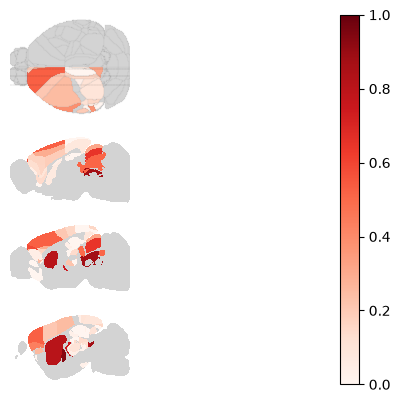

In [41]:
from dynamic_routing_analysis import plot_utils

regions=results_pd['structure']
values=results_pd['normed_stimulus_mean']

chart,x = plot_utils.plot_brain_heatmap(
    regions=regions,
    values=values,
    sagittal_planes=np.array([-300,-1000,-2000,]),
    #sagittal_planes=(-1000,-2000,),
    interactive=True,
    cmap='Reds',
    clevels=(0,1),
)

In [42]:
# chart.set_size_inches(12,12)
chart

alt.HConcatChart(...)

In [27]:
ccf_utils.get_ccf_structure_info('MOs')['name']

'Secondary motor area'